## 절대경로로 해서 데이터분석하기


In [4]:
from pathlib import Path
import os
import pandas as pd

current_path = Path.cwd()
parent_path = current_path.parent
file_path = parent_path/'second_week/data_csv'
file = file_path/'강원특별자치도_담배소매업.csv'
df = pd.read_csv(file,encoding = 'cp949')
df.columns.to_list()

['번호',
 '개방서비스명',
 '개방서비스아이디',
 '개방자치단체코드',
 '관리번호',
 '인허가일자',
 '인허가취소일자',
 '영업상태구분코드',
 '영업상태명',
 '상세영업상태코드',
 '상세영업상태명',
 '폐업일자',
 '휴업시작일자',
 '휴업종료일자',
 '재개업일자',
 '소재지전화',
 '소재지면적',
 '소재지우편번호',
 '소재지전체주소',
 '도로명전체주소',
 '도로명우편번호',
 '사업장명',
 '최종수정시점',
 '데이터갱신구분',
 '데이터갱신일자',
 '업태구분명',
 '좌표정보x(epsg5174)',
 '좌표정보y(epsg5174)',
 '지정일자',
 '민원종류명',
 'Unnamed: 30']

## 각 컬럼간의 유기관계에 대해 따져보기

In [10]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 30703 entries, 0 to 30702
Data columns (total 31 columns):
 #   Column           Non-Null Count  Dtype  
---  ------           --------------  -----  
 0   번호               30703 non-null  int64  
 1   개방서비스명           30703 non-null  object 
 2   개방서비스아이디         30703 non-null  object 
 3   개방자치단체코드         30703 non-null  int64  
 4   관리번호             30703 non-null  object 
 5   인허가일자            30592 non-null  object 
 6   인허가취소일자          3298 non-null   object 
 7   영업상태구분코드         30703 non-null  int64  
 8   영업상태명            30703 non-null  object 
 9   상세영업상태코드         30703 non-null  object 
 10  상세영업상태명          30536 non-null  object 
 11  폐업일자             18531 non-null  object 
 12  휴업시작일자           412 non-null    object 
 13  휴업종료일자           407 non-null    object 
 14  재개업일자            0 non-null      float64
 15  소재지전화            20333 non-null  object 
 16  소재지면적            0 non-null      float64
 17  소재지우편번호     

In [11]:
import numpy as np
total_size = df['폐업일자'].isnull().size
total_size
def make_autopct_with_count(pct):
    absolute_count = int(np.round(pct*total_size/100))
    return f"{pct:.1f}%\n{absolute_count}명"


([<matplotlib.patches.Wedge at 0x2394f4a5e50>,
 [Text(0.3515865988078711, 1.0422988360056407, '폐업일자 있음(Null)'),
  Text(-0.35158638343549803, -1.042298908654685, '폐업일자 없음(Non Null)')],
 [Text(0.19177450844065694, 0.5685266378212585, '39.6%\n12172명'),
  Text(-0.19177439096481708, -0.5685266774480099, '60.4%\n18531명')])

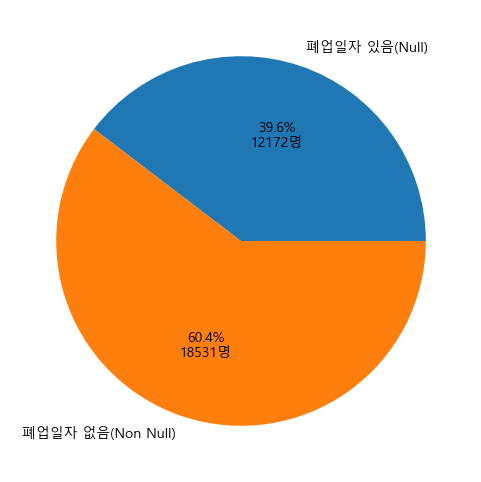

In [18]:
import matplotlib.pyplot as plt
import warnings
plt.rc('font',family = 'Malgun Gothic')
plt.rcParams['axes.unicode_minus'] = False
warnings.filterwarnings('ignore')
counts = df['폐업일자'].isnull().value_counts()
labels = ['폐업일자 있음(Null)','폐업일자 없음(Non Null)']
sizes = [counts.get(True,0),counts.get(False,0)]
plt.figure(figsize = (6,6))
plt.pie(sizes, labels = labels, autopct=make_autopct_with_count)